## TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

In [25]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("amazonreviews.tsv", sep='\t')

# Remove duplicate rows
df.drop_duplicates(inplace=True)
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [26]:
# Check missing values
df.isnull().sum()

label     0
review    0
dtype: int64

In [44]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\Navya D
[nltk_data]     C\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
def clean_text(text):
    text = text.lower()                      # convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove special characters
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return " ".join(words)

In [29]:
df['clean_review'] = df['review'].apply(clean_text)

In [30]:
stop_words = set(stopwords.words('english'))

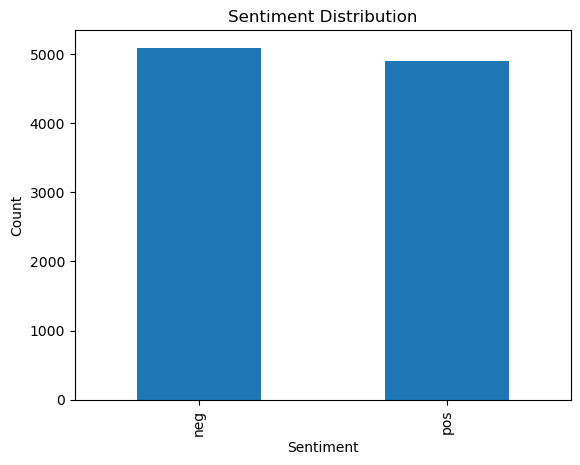

In [31]:
import matplotlib.pyplot as plt

# Count labels
df['label'].value_counts()

# Plot
df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [32]:
!pip install wordcloud

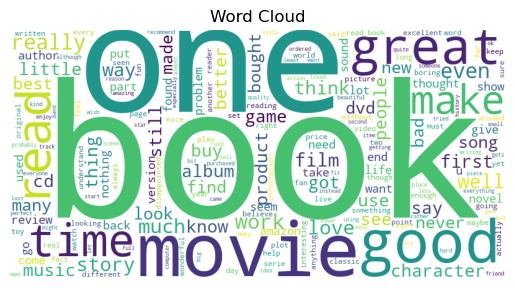

In [33]:
from wordcloud import WordCloud

# Combine all text
text = " ".join(df['clean_review'])

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

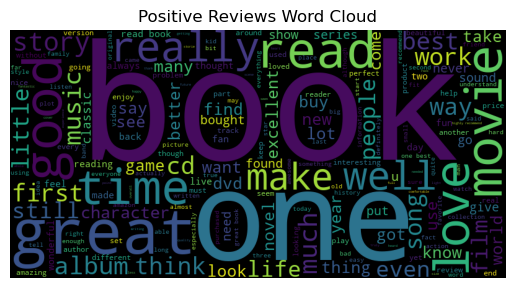

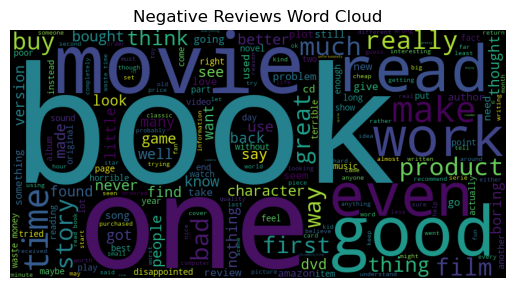

In [34]:
# Positive reviews
pos_text = " ".join(df[df['label']=='pos']['clean_review'])

wc_pos = WordCloud(width=800, height=400).generate(pos_text)
plt.imshow(wc_pos)
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

# Negative reviews
neg_text = " ".join(df[df['label']=='neg']['clean_review'])

wc_neg = WordCloud(width=800, height=400).generate(neg_text)
plt.imshow(wc_neg)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numerical vectors
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])

# Convert labels
y = df['label'].map({'pos': 1, 'neg': 0})

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [38]:
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_nn = Sequential()
model_nn.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model_nn.add(Dense(1, activation='sigmoid'))

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_nn.fit(X_train.toarray(), y_train, epochs=5, batch_size=32)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8019 - loss: 0.4899    
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9140 - loss: 0.2392 
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9475 - loss: 0.1632 
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9650 - loss: 0.1159 
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9797 - loss: 0.0824 


In [40]:
from sklearn.metrics import accuracy_score, f1_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.851
SVM Accuracy: 0.86


In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# 5-fold cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.8595 0.83   0.827  0.8455 0.8505]
Mean accuracy: 0.8424999999999999


In [42]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.851
F1 Score: 0.8443051201671892

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86      1037
           1       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

